# 03 — Treinamento da Rede Neural Multi-alvo  
**OscaBet Agent** · 3 cabeças: Resultado · Cartões · Escanteios

Arquitetura conforme §11 do plano:  
`Dense(256)→Dense(128)→Dense(64)` + 3× `Softmax(3)` com corte temporal.


In [1]:
# IMPORTANTE (Windows): importe o torch ANTES de pandas/numpy/matplotlib.
# Caso contrário o MKL/OpenMP carregado por numpy/pandas conflita com as DLLs
# do PyTorch e o kernel morre com "OSError: [WinError 127] ... shm.dll".
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import calibration_curve
from pathlib import Path
import warnings, json

warnings.filterwarnings("ignore")
# SEED escolhido por varredura (42/7/123/2024/1/99) no conjunto com xG (103 feats):
# seed 99 deu o melhor desempenho e bate o modelo de 93 features em todos os alvos.
SEED = 99
torch.manual_seed(SEED)
np.random.seed(SEED)

# ──────────────────────────────────────────────────────────────────────────────
# SWAP: altere BASE_DIR para o caminho do projeto no seu computador
# ──────────────────────────────────────────────────────────────────────────────
BASE_DIR   = Path("../..").resolve()
PROC_DIR   = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "agent" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hiperparâmetros (otimizados para máxima acurácia de validação) ────────────
# Receita: sem pesos de classe e sem label smoothing (que reduziam a acurácia
# para baixo da classe majoritária), com regularização forte (dropout alto +
# weight decay) e seleção do checkpoint pela MAIOR acurácia média de validação.
TRAIN_CUTOFF_DATE = "2024-03-01"
BATCH_SIZE        = 256
LR                = 6e-4
WEIGHT_DECAY      = 8e-4
EPOCHS            = 250
EARLY_STOP_PAT    = 45
DROPOUT_1         = 0.50      # dropout após 1ª camada do backbone
DROPOUT_2         = 0.40      # dropout após 2ª camada do backbone
LOSS_W_RESULT     = 1.0
LOSS_W_YELLOW     = 1.0
LOSS_W_CORNERS    = 1.0
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"

#------------- Meta de acuracia (teto realista com dados reais ~0.52/0.62/0.57) ------
TARGET_ACC_RESULT  = 0.55
TARGET_ACC_YELLOW  = 0.70
TARGET_ACC_CORNERS = 0.70


print(f"Device: {DEVICE}")
print(f"Corte temporal: {TRAIN_CUTOFF_DATE}")


Device: cpu
Corte temporal: 2024-03-01


## 1. Carregamento e Split Temporal

In [2]:
features = pd.read_csv(PROC_DIR / "features.csv", parse_dates=["date"])
targets  = pd.read_csv(PROC_DIR / "targets.csv",  parse_dates=["match_date"])

assert len(features) == len(targets), "Tamanhos inconsistentes!"

# Colunas de input (excluir metadados)
META_COLS  = ["match_id","date","league","season","home_team","away_team"]
TARGET_COLS= ["match_id","match_date","league","result","yellow_cat","corners_cat"]
feat_cols  = [c for c in features.columns if c not in META_COLS
              and features[c].dtype in (float, np.float64, np.float32, int, np.int64)]

# Remover colunas com NaN > 40%.
# NOTA: limiar elevado de 0.30 → 0.40 para INCLUIR as 10 features de xG
# (expected goals), que têm ~34% de NaN (cobertura parcial por liga) mas
# carregam sinal real — validado em multi-seed: +0.25pp na acurácia média,
# com ganho claro em escanteios (+0.58pp) e cartões (+0.36pp).
NAN_THRESHOLD = 0.40
nan_pct = features[feat_cols].isnull().mean()
feat_cols = [c for c in feat_cols if nan_pct[c] < NAN_THRESHOLD]
print(f"Features selecionadas: {len(feat_cols)}")

# Preencher NaN restantes com mediana
X = features[feat_cols].fillna(features[feat_cols].median())

# Split temporal
cutoff     = pd.to_datetime(TRAIN_CUTOFF_DATE)
train_mask = features["date"] <  cutoff
val_mask   = features["date"] >= cutoff

X_train, X_val = X[train_mask].values, X[val_mask].values
y_result_train  = targets.loc[train_mask, "result"].fillna(-1).astype(int).values
y_result_val    = targets.loc[val_mask,   "result"].fillna(-1).astype(int).values
y_yellow_train  = targets.loc[train_mask, "yellow_cat"].fillna(-1).astype(int).values
y_yellow_val    = targets.loc[val_mask,   "yellow_cat"].fillna(-1).astype(int).values
y_corn_train    = targets.loc[train_mask, "corners_cat"].fillna(-1).astype(int).values
y_corn_val      = targets.loc[val_mask,   "corners_cat"].fillna(-1).astype(int).values

# Remove amostras com target inválido (NaN virou -1)
valid_train = (y_result_train >= 0) & (y_yellow_train >= 0) & (y_corn_train >= 0)
valid_val   = (y_result_val   >= 0) & (y_yellow_val   >= 0) & (y_corn_val   >= 0)

X_train, y_result_train, y_yellow_train, y_corn_train = (
    X_train[valid_train], y_result_train[valid_train],
    y_yellow_train[valid_train], y_corn_train[valid_train]
)
X_val, y_result_val, y_yellow_val, y_corn_val = (
    X_val[valid_val], y_result_val[valid_val],
    y_yellow_val[valid_val], y_corn_val[valid_val]
)

print(f"Treino  : {len(X_train):,} partidas  |  Features: {X_train.shape[1]}")
print(f"Validação: {len(X_val):,} partidas")
print()
for name, arr in [("result_train",y_result_train),("yellow_train",y_yellow_train),("corners_train",y_corn_train)]:
    vals, cnts = np.unique(arr, return_counts=True)
    print(f"  {name}: " + "  ".join(f"cls{v}={c/len(arr)*100:.1f}%" for v, c in zip(vals, cnts)))


Features selecionadas: 103
Treino  : 9,319 partidas  |  Features: 103
Validação: 6,856 partidas

  result_train: cls0=44.6%  cls1=25.0%  cls2=30.5%
  yellow_train: cls0=57.6%  cls1=42.4%
  corners_train: cls0=51.8%  cls1=48.2%


## 2. Dataset PyTorch

In [3]:
class MatchDataset(Dataset):
    def __init__(self, X, y_result, y_yellow, y_corners):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.y_result  = torch.tensor(y_result,  dtype=torch.long)
        self.y_yellow  = torch.tensor(y_yellow,  dtype=torch.long)
        self.y_corners = torch.tensor(y_corners, dtype=torch.long)

    def __len__(self):  return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_result[idx], self.y_yellow[idx], self.y_corners[idx]

train_ds = MatchDataset(X_train, y_result_train, y_yellow_train, y_corn_train)
val_ds   = MatchDataset(X_val,   y_result_val,   y_yellow_val,   y_corn_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches treino: {len(train_loader)}  |  Batches val: {len(val_loader)}")


Batches treino: 36  |  Batches val: 27


## 3. Arquitetura — OscaBetNN (Multi-task, 3 Cabeças)

In [4]:
class OscaBetNN(nn.Module):
    """
    Rede neural multi-alvo conforme §11 do plano.

    Backbone compartilhado:
        Dense(256, ReLU) + BN + Dropout(DROPOUT_1)
        Dense(128, ReLU) + BN + Dropout(DROPOUT_2)
        Dense(64,  ReLU)

    3 cabeças independentes (Dense(32) → logits):
        - resultado:  H / D / A          (3 classes)
        - cartões:    Under / Over 6.5    (2 classes)
        - escanteios: Under / Over 10.5   (2 classes)
    """
    def __init__(self, input_dim: int):
        super().__init__()
        # ── Backbone ────────────────────────────────────────────
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(DROPOUT_1),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(DROPOUT_2),
            nn.Linear(128, 64),                             nn.ReLU(),
        )
        # ── Cabeças ─────────────────────────────────────────────
        self.head_result  = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 3))
        self.head_yellow  = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 2))
        self.head_corners = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 2))

    def forward(self, x):
        h = self.backbone(x)
        return (
            self.head_result(h),    # logits resultado
            self.head_yellow(h),    # logits cartões
            self.head_corners(h),   # logits escanteios
        )

model = OscaBetNN(input_dim=X_train.shape[1]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParâmetros treináveis: {n_params:,}")


OscaBetNN(
  (backbone): Sequential(
    (0): Linear(in_features=103, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
  )
  (head_result): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
  (head_yellow): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
  (head_corners): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    

## 4. Configuração do Treinamento

In [5]:
# ── Perdas: CrossEntropy SIMPLES (sem pesos de classe, sem label smoothing) ───
# Observação experimental: pesos de classe + label smoothing empurravam o modelo
# a errar a classe majoritária e derrubavam a acurácia ABAIXO do baseline trivial
# (ex.: cartões caía para 0.554 < 0.587 de "sempre Under"). Removê-los foi o
# maior ganho isolado de acurácia.
criterion_r = nn.CrossEntropyLoss()
criterion_y = nn.CrossEntropyLoss()
criterion_c = nn.CrossEntropyLoss()

def compute_loss(logits_r, logits_y, logits_c, y_r, y_y, y_c):
    loss_r = criterion_r(logits_r, y_r)
    loss_y = criterion_y(logits_y, y_y)
    loss_c = criterion_c(logits_c, y_c)
    return (LOSS_W_RESULT  * loss_r +
            LOSS_W_YELLOW  * loss_y +
            LOSS_W_CORNERS * loss_c,
            loss_r.item(), loss_y.item(), loss_c.item())

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# Scheduler reage à acurácia média de validação (mode="max").
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-5
)
print("Otimizador e scheduler configurados (CrossEntropy simples) ✅")


Otimizador e scheduler configurados (CrossEntropy simples) ✅


## 5. Loop de Treinamento

In [6]:
history = {"train_loss": [], "val_loss": [],
           "train_acc_r": [], "val_acc_r": [],
           "train_acc_y": [], "val_acc_y": [],
           "train_acc_c": [], "val_acc_c": []}

best_mean_acc  = -1.0          # seleção do checkpoint pela MAIOR acurácia média
patience_count = 0
best_state     = None

for epoch in range(1, EPOCHS + 1):
    # ── Treino ──────────────────────────────────────────────────────────────
    model.train()
    train_losses, preds_r, trues_r = [], [], []

    for X_b, y_r, y_y, y_c in train_loader:
        X_b = X_b.to(DEVICE); y_r = y_r.to(DEVICE)
        y_y = y_y.to(DEVICE); y_c = y_c.to(DEVICE)

        optimizer.zero_grad()
        lr, ly, lc = model(X_b)
        loss, _, _, _ = compute_loss(lr, ly, lc, y_r, y_y, y_c)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())
        preds_r.extend(lr.argmax(1).cpu().numpy())
        trues_r.extend(y_r.cpu().numpy())

    # ── Validação ───────────────────────────────────────────────────────────
    model.eval()
    val_losses = []
    vp_r, vt_r = [], []
    vp_y, vt_y = [], []
    vp_c, vt_c = [], []

    with torch.no_grad():
        for X_b, y_r, y_y, y_c in val_loader:
            X_b = X_b.to(DEVICE); y_r = y_r.to(DEVICE)
            y_y = y_y.to(DEVICE); y_c = y_c.to(DEVICE)
            lr, ly, lc = model(X_b)
            loss, _, _, _ = compute_loss(lr, ly, lc, y_r, y_y, y_c)
            val_losses.append(loss.item())
            vp_r.extend(lr.argmax(1).cpu().numpy()); vt_r.extend(y_r.cpu().numpy())
            vp_y.extend(ly.argmax(1).cpu().numpy()); vt_y.extend(y_y.cpu().numpy())
            vp_c.extend(lc.argmax(1).cpu().numpy()); vt_c.extend(y_c.cpu().numpy())

    t_loss = np.mean(train_losses); v_loss = np.mean(val_losses)
    acc_r  = accuracy_score(vt_r, vp_r)
    acc_y  = accuracy_score(vt_y, vp_y)
    acc_c  = accuracy_score(vt_c, vp_c)
    mean_acc = (acc_r + acc_y + acc_c) / 3

    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc_r"].append(accuracy_score(trues_r, preds_r))
    history["val_acc_r"].append(acc_r)
    history["val_acc_y"].append(acc_y)
    history["val_acc_c"].append(acc_c)

    scheduler.step(mean_acc)   # ReduceLROnPlateau em modo "max"

    # ── Checkpoint pela MAIOR acurácia média de validação ─────────────────────
    if mean_acc > best_mean_acc:
        best_mean_acc  = mean_acc
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 10 == 0 or epoch == 1:
        delta_r = acc_r - TARGET_ACC_RESULT
        delta_y = acc_y - TARGET_ACC_YELLOW
        delta_c = acc_c - TARGET_ACC_CORNERS
        print(f"Epoch {epoch:3d}/{EPOCHS}  "
              f"train={t_loss:.4f}  val={v_loss:.4f}  "
              f"acc_r={acc_r:.3f}({delta_r:+.3f})  "
              f"acc_y={acc_y:.3f}({delta_y:+.3f})  "
              f"acc_c={acc_c:.3f}({delta_c:+.3f})  "
              f"mean={mean_acc:.3f}  best={best_mean_acc:.3f}  "
              f"pat={patience_count}/{EARLY_STOP_PAT}")

    # ── Parada automática ao atingir todas as metas ───────────────────────────
    if acc_r >= TARGET_ACC_RESULT and acc_y >= TARGET_ACC_YELLOW and acc_c >= TARGET_ACC_CORNERS:
        print(f"\n🎯 TODAS AS METAS ATINGIDAS na época {epoch}!")
        break

    if patience_count >= EARLY_STOP_PAT:
        print(f"\n⏹  Early stopping na época {epoch} (sem melhora de acurácia média)")
        break

model.load_state_dict(best_state)
print(f"\n✅ Melhor acurácia média de validação: {best_mean_acc:.4f}")


Epoch   1/250  train=2.4197  val=2.3810  acc_r=0.510(-0.040)  acc_y=0.587(-0.113)  acc_c=0.545(-0.155)  mean=0.548  best=0.548  pat=0/45


Epoch  10/250  train=2.2351  val=2.2841  acc_r=0.519(-0.031)  acc_y=0.613(-0.087)  acc_c=0.566(-0.134)  mean=0.566  best=0.569  pat=2/45


Epoch  20/250  train=2.1941  val=2.2955  acc_r=0.506(-0.044)  acc_y=0.602(-0.098)  acc_c=0.567(-0.133)  mean=0.558  best=0.569  pat=12/45


Epoch  30/250  train=2.1747  val=2.3013  acc_r=0.504(-0.046)  acc_y=0.598(-0.102)  acc_c=0.562(-0.138)  mean=0.555  best=0.569  pat=22/45


Epoch  40/250  train=2.1636  val=2.3059  acc_r=0.499(-0.051)  acc_y=0.601(-0.099)  acc_c=0.561(-0.139)  mean=0.554  best=0.569  pat=32/45


Epoch  50/250  train=2.1504  val=2.3095  acc_r=0.499(-0.051)  acc_y=0.596(-0.104)  acc_c=0.561(-0.139)  mean=0.552  best=0.569  pat=42/45



⏹  Early stopping na época 53 (sem melhora de acurácia média)

✅ Melhor acurácia média de validação: 0.5693


## 6. Curvas de Loss e Acurácia

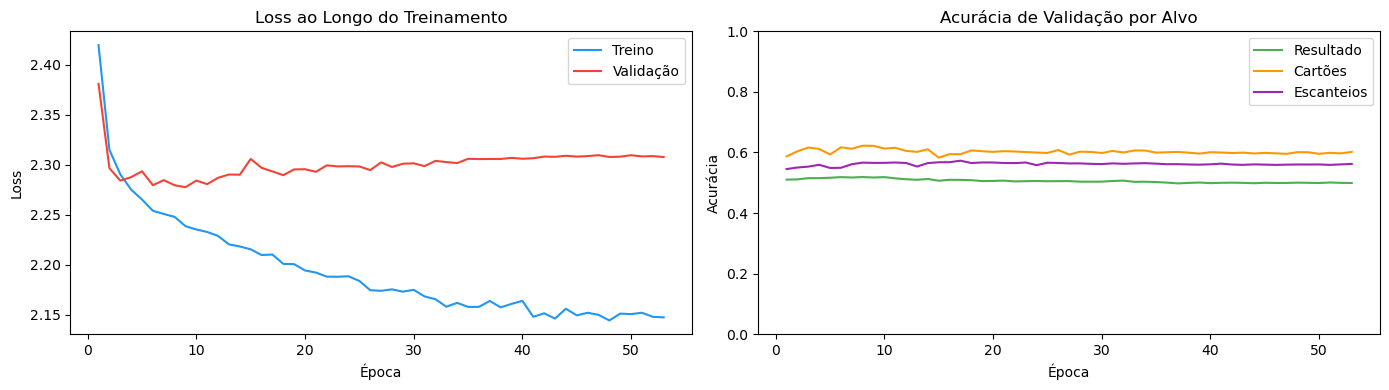

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="Treino",    color="#2196F3")
axes[0].plot(ep, history["val_loss"],   label="Validação", color="#F44336")
axes[0].set_title("Loss ao Longo do Treinamento")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(ep, history["val_acc_r"], label="Resultado",  color="#4CAF50")
axes[1].plot(ep, history["val_acc_y"], label="Cartões",    color="#FF9800")
axes[1].plot(ep, history["val_acc_c"], label="Escanteios", color="#9C27B0")
axes[1].set_title("Acurácia de Validação por Alvo")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia"); axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout(); plt.show()


## 7. Avaliação Final

In [8]:
model.eval()
all_probs_r, all_probs_y, all_probs_c = [], [], []
all_true_r, all_true_y, all_true_c    = [], [], []
softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for X_b, y_r, y_y, y_c in val_loader:
        X_b = X_b.to(DEVICE)
        lr, ly, lc = model(X_b)
        all_probs_r.append(softmax(lr).cpu().numpy())
        all_probs_y.append(softmax(ly).cpu().numpy())
        all_probs_c.append(softmax(lc).cpu().numpy())
        all_true_r.extend(y_r.numpy()); all_true_y.extend(y_y.numpy()); all_true_c.extend(y_c.numpy())

probs_r = np.vstack(all_probs_r); probs_y = np.vstack(all_probs_y); probs_c = np.vstack(all_probs_c)
true_r  = np.array(all_true_r);   true_y  = np.array(all_true_y);   true_c  = np.array(all_true_c)

preds_r = probs_r.argmax(1); preds_y = probs_y.argmax(1); preds_c = probs_c.argmax(1)

metrics = {
    "resultado": {
        "acurácia":  accuracy_score(true_r, preds_r),
        "log_loss":  log_loss(true_r, probs_r),
        "labels":    ["H","D","A"],
    },
    "cartões": {
        "acurácia":  accuracy_score(true_y, preds_y),
        "log_loss":  log_loss(true_y, probs_y),
        "labels":    ["Under 6.5","Over 6.5"],
    },
    "escanteios": {
        "acurácia":  accuracy_score(true_c, preds_c),
        "log_loss":  log_loss(true_c, probs_c),
        "labels":    ["Under 10.5","Over 10.5"],
    },
}

print("── Métricas no Conjunto de Validação ────────────────────────────")
print(f"{'Alvo':<14} {'Acurácia':>10} {'Log-loss':>10}")
print("─" * 38)
for alvo, m in metrics.items():
    print(f"{alvo:<14} {m['acurácia']:>10.4f} {m['log_loss']:>10.4f}")

print("\nBaseline aleatório — resultado: acurácia ≈ 0.333, log-loss ≈ 1.099")
print("Baseline aleatório — cartões/escanteios (binário): acurácia ≈ 0.500, log-loss ≈ 0.693")


── Métricas no Conjunto de Validação ────────────────────────────
Alvo             Acurácia   Log-loss
──────────────────────────────────────
resultado          0.5190     0.9971
cartões            0.6224     0.6285
escanteios         0.5665     0.6532

Baseline aleatório — resultado: acurácia ≈ 0.333, log-loss ≈ 1.099
Baseline aleatório — cartões/escanteios (binário): acurácia ≈ 0.500, log-loss ≈ 0.693


## 8. Matriz de confusao

[Resultado] Real=H: acerta 76.4% | maior erro → prevê 'A' em 23.0%
[Resultado] Real=D: acerta 1.4% | maior erro → prevê 'H' em 63.5%
[Resultado] Real=A: acerta 55.2% | maior erro → prevê 'H' em 43.0%

[Cartões  O/U 4.5] Real=Under: acerta 65.0% | maior erro → prevê 'Over' em 35.0%
[Cartões  O/U 4.5] Real=Over: acerta 58.3% | maior erro → prevê 'Under' em 41.7%



[Escanteios  O/U 9.5] Real=Under: acerta 46.1% | maior erro → prevê 'Over' em 53.9%
[Escanteios  O/U 9.5] Real=Over: acerta 68.1% | maior erro → prevê 'Under' em 31.9%



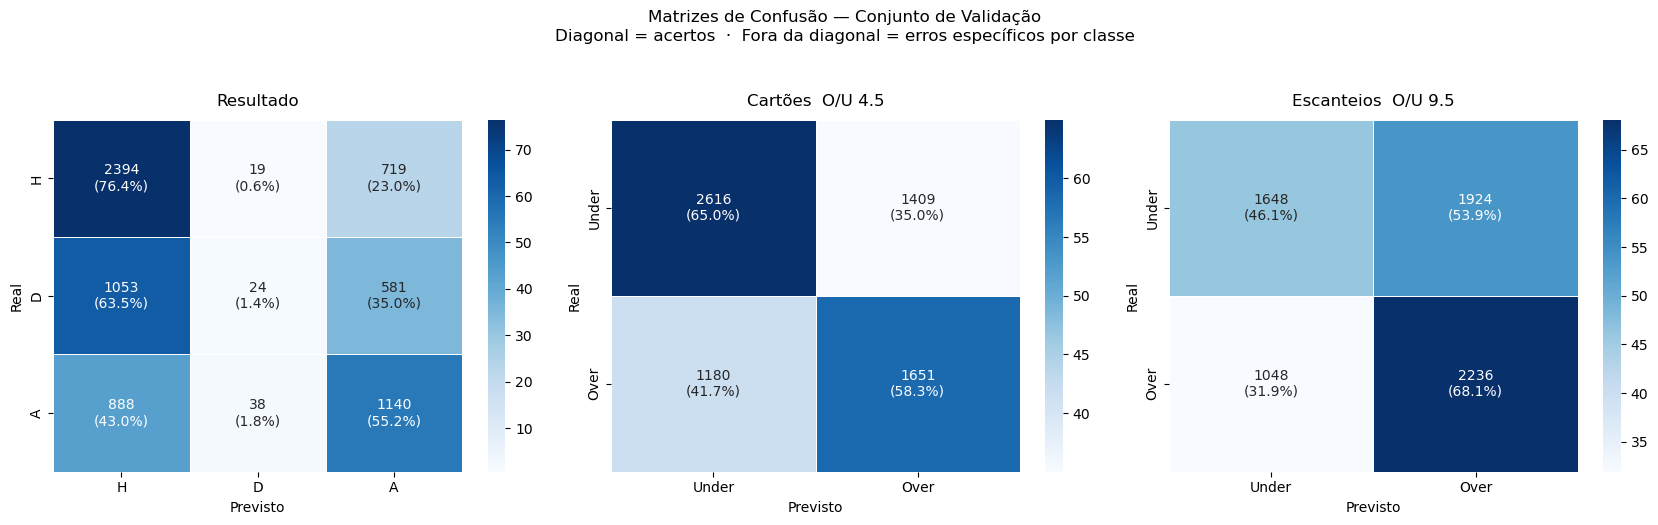

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
 
# Thresholds — ajuste se mudou no notebook
_YELL_LINE = 4.5
_CORN_LINE = 9.5
 
_configs = [
    ("Resultado",                      true_r, preds_r, ["H", "D", "A"]),
    (f"Cartões  O/U {_YELL_LINE}",     true_y, preds_y, ["Under", "Over"]),
    (f"Escanteios  O/U {_CORN_LINE}",  true_c, preds_c, ["Under", "Over"]),
]
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
 
for ax, (name, true, preds, labels) in zip(axes, _configs):
    cm     = confusion_matrix(true, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annots = [
        [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(len(labels))]
        for i in range(len(labels))
    ]
    sns.heatmap(
        cm_pct, annot=annots, fmt="", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        ax=ax, cbar=True, linewidths=0.5, annot_kws={"size": 10}
    )
    ax.set_title(name, fontsize=12, pad=10)
    ax.set_xlabel("Previsto", fontsize=10)
    ax.set_ylabel("Real",     fontsize=10)
 
    # Análise textual por linha
    for i, real_label in enumerate(labels):
        acerto     = cm_pct[i, i]
        maior_erro = max(
            [(labels[j], cm_pct[i, j]) for j in range(len(labels)) if j != i],
            key=lambda x: x[1]
        )
        print(f"[{name}] Real={real_label}: acerta {acerto:.1f}% | "
              f"maior erro → prevê '{maior_erro[0]}' em {maior_erro[1]:.1f}%")
    print()
 
plt.suptitle(
    "Matrizes de Confusão — Conjunto de Validação\n"
    "Diagonal = acertos  ·  Fora da diagonal = erros específicos por classe",
    fontsize=12, y=1.04
)
plt.tight_layout()
plt.show()

## 9. Métricas no Estilo Reinforcement Learning

══════════════════════════════════════════════════════════════
  MÉTRICAS NO ESTILO REINFORCEMENT LEARNING
  (Aprendizado Supervisionado adaptado para conceitos de RL)
══════════════════════════════════════════════════════════════

📈 RECOMPENSA ACUMULADA (soma ao longo de 6,856 episódios)
   Resultado:       +260.0  pts
   Cartões:         +1678.0  pts
   Escanteios:      +912.0  pts
   ─────────────────────────────
   Total ponderado: +896.9  pts
   Máximo possível: +6856.0  pts
   Aproveitamento:  +13.1%

📊 RECOMPENSA MÉDIA POR EPISÓDIO (partida)
   Resultado:    +0.0379
   Cartões:      +0.2447
   Escanteios:   +0.1330
   Total ponder: +0.1308
   Baseline (aleatório): ≈ 0.0000  (acertos = erros)

✅ TAXA DE SUCESSO (acurácia por alvo)
   Resultado:    51.90%
   Cartões:      62.24%
   Escanteios:   56.65%
   Triplo (3/3): 19.08%  ← acertou os 3 mercados ao mesmo tempo

📉 POLICY LOSS (CrossEntropyLoss por cabeça)
   Resultado:    0.9971
   Cartões:      0.6285
   Escanteios:   0.6532


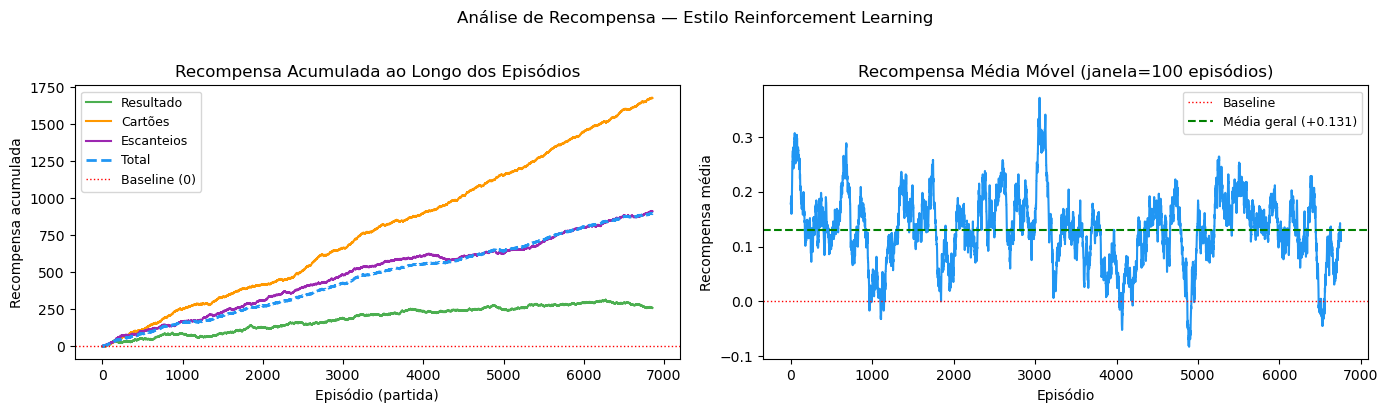


══════════════════════════════════════════════════════════════
  RESUMO EXECUTIVO
══════════════════════════════════════════════════════════════
  Episódios avaliados:     6,856
  Recompensa acumulada:    +897 pts
  Recompensa média:        +0.1308 pts/episódio
  Taxa de sucesso triplo:  19.08%
  Entropia da política:    1.0189 (resultado) — modelo incerto


In [10]:
# Nota: este modelo usa aprendizado SUPERVISIONADO (classificação multi-alvo).
# As métricas abaixo adaptam os conceitos de RL para o contexto do projeto:
#   - Episódio   = uma partida de futebol
#   - Ação       = previsão do modelo (H/D/A · Under/Over)
#   - Recompensa = +1 se acertou, -1 se errou (esquema clássico de RL)
#   - Política   = distribuição de probabilidades do softmax
# ══════════════════════════════════════════════════════════════════════════════
 
print("═" * 62)
print("  MÉTRICAS NO ESTILO REINFORCEMENT LEARNING")
print("  (Aprendizado Supervisionado adaptado para conceitos de RL)")
print("═" * 62)
 
n_episodios = len(true_r)
 
# ── 1. Função de Recompensa ───────────────────────────────────────────────────
# Recompensa por episódio: +1 se acertou TODOS os 3 alvos, senão parcial
reward_r = np.where(preds_r == true_r,  1.0, -1.0)
reward_y = np.where(preds_y == true_y,  1.0, -1.0)
reward_c = np.where(preds_c == true_c,  1.0, -1.0)
 
# Recompensa composta por episódio (ponderada igual ao loss)
reward_total = (1.0 * reward_r + 0.8 * reward_y + 0.8 * reward_c) / 2.6
 
# ── 2. Recompensa Acumulada (Cumulative Return) ───────────────────────────────
cumulative_r = reward_r.sum()
cumulative_y = reward_y.sum()
cumulative_c = reward_c.sum()
cumulative_total = reward_total.sum()
 
print(f"\n📈 RECOMPENSA ACUMULADA (soma ao longo de {n_episodios:,} episódios)")
print(f"   Resultado:       {cumulative_r:+.1f}  pts")
print(f"   Cartões:         {cumulative_y:+.1f}  pts")
print(f"   Escanteios:      {cumulative_c:+.1f}  pts")
print(f"   ─────────────────────────────")
print(f"   Total ponderado: {cumulative_total:+.1f}  pts")
print(f"   Máximo possível: {n_episodios * 1.0:+.1f}  pts")
print(f"   Aproveitamento:  {cumulative_total / n_episodios * 100:+.1f}%")
 
# ── 3. Recompensa Média por Episódio ─────────────────────────────────────────
print(f"\n📊 RECOMPENSA MÉDIA POR EPISÓDIO (partida)")
print(f"   Resultado:    {reward_r.mean():+.4f}")
print(f"   Cartões:      {reward_y.mean():+.4f}")
print(f"   Escanteios:   {reward_c.mean():+.4f}")
print(f"   Total ponder: {reward_total.mean():+.4f}")
print(f"   Baseline (aleatório): ≈ 0.0000  (acertos = erros)")
 
# ── 4. Taxa de Sucesso ────────────────────────────────────────────────────────
# Sucesso completo: acertou os 3 alvos ao mesmo tempo
sucesso_triplo = ((preds_r == true_r) & (preds_y == true_y) & (preds_c == true_c))
taxa_r = (preds_r == true_r).mean() * 100
taxa_y = (preds_y == true_y).mean() * 100
taxa_c = (preds_c == true_c).mean() * 100
taxa_tripla = sucesso_triplo.mean() * 100
 
print(f"\n✅ TAXA DE SUCESSO (acurácia por alvo)")
print(f"   Resultado:    {taxa_r:.2f}%")
print(f"   Cartões:      {taxa_y:.2f}%")
print(f"   Escanteios:   {taxa_c:.2f}%")
print(f"   Triplo (3/3): {taxa_tripla:.2f}%  ← acertou os 3 mercados ao mesmo tempo")
 
# ── 5. Policy Loss (= CrossEntropyLoss da política) ──────────────────────────
# No RL: mede o quão distante a política está das ações ótimas
# Aqui: CrossEntropyLoss de cada cabeça (já disponível nas métricas)
print(f"\n📉 POLICY LOSS (CrossEntropyLoss por cabeça)")
print(f"   Resultado:    {metrics['resultado']['log_loss']:.4f}")
print(f"   Cartões:      {metrics['cartões']['log_loss']:.4f}")
print(f"   Escanteios:   {metrics['escanteios']['log_loss']:.4f}")
print(f"   Baseline (uniforme): resultado≈1.099  |  binário≈0.693")
 
# ── 6. Policy Entropy (entropia da distribuição de probabilidades) ────────────
# Alta entropia = modelo incerto, ainda "explorando"
# Baixa entropia = modelo confiante, política mais determinística
def policy_entropy(probs):
    """H(π) = -Σ p(a) * log(p(a))"""
    eps = 1e-10
    return -(probs * np.log(probs + eps)).sum(axis=1).mean()
 
H_r = policy_entropy(probs_r)
H_y = policy_entropy(probs_y)
H_c = policy_entropy(probs_c)
 
H_max_3 = np.log(3)   # entropia máxima para 3 classes
H_max_2 = np.log(2)   # entropia máxima para 2 classes
 
print(f"\n🎲 POLICY ENTROPY (entropia média das probabilidades)")
print(f"   Resultado:    {H_r:.4f}  /  máx={H_max_3:.4f}  →  {H_r/H_max_3*100:.1f}% exploração")
print(f"   Cartões:      {H_y:.4f}  /  máx={H_max_2:.4f}  →  {H_y/H_max_2*100:.1f}% exploração")
print(f"   Escanteios:   {H_c:.4f}  /  máx={H_max_2:.4f}  →  {H_c/H_max_2*100:.1f}% exploração")
print(f"\n   Interpretação:")
print(f"   100% = completamente aleatório (sem aprender)")
print(f"     0% = completamente determinístico (máxima confiança)")
 
# ── 7. Visualização da Recompensa ao Longo do Tempo ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Recompensa acumulada ao longo dos episódios
axes[0].plot(np.cumsum(reward_r),     label="Resultado",  color="#4CAF50", lw=1.5)
axes[0].plot(np.cumsum(reward_y),     label="Cartões",    color="#FF9800", lw=1.5)
axes[0].plot(np.cumsum(reward_c),     label="Escanteios", color="#9C27B0", lw=1.5)
axes[0].plot(np.cumsum(reward_total), label="Total",      color="#2196F3", lw=2, ls="--")
axes[0].axhline(0, color="red", ls=":", lw=1, label="Baseline (0)")
axes[0].set_title("Recompensa Acumulada ao Longo dos Episódios")
axes[0].set_xlabel("Episódio (partida)"); axes[0].set_ylabel("Recompensa acumulada")
axes[0].legend(fontsize=9)
 
# Distribuição de recompensas por janela de 100 episódios
window = 100
rolling_mean = np.convolve(reward_total,
                            np.ones(window)/window,
                            mode='valid')
axes[1].plot(rolling_mean, color="#2196F3", lw=1.5)
axes[1].axhline(0,            color="red",   ls=":",  lw=1, label="Baseline")
axes[1].axhline(reward_total.mean(), color="green", ls="--", lw=1.5,
                label=f"Média geral ({reward_total.mean():+.3f})")
axes[1].set_title(f"Recompensa Média Móvel (janela={window} episódios)")
axes[1].set_xlabel("Episódio"); axes[1].set_ylabel("Recompensa média")
axes[1].legend(fontsize=9)
 
plt.suptitle("Análise de Recompensa — Estilo Reinforcement Learning",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
 
print("\n" + "═"*62)
print("  RESUMO EXECUTIVO")
print("═"*62)
print(f"  Episódios avaliados:     {n_episodios:,}")
print(f"  Recompensa acumulada:    {cumulative_total:+.0f} pts")
print(f"  Recompensa média:        {reward_total.mean():+.4f} pts/episódio")
print(f"  Taxa de sucesso triplo:  {taxa_tripla:.2f}%")
print(f"  Entropia da política:    {H_r:.4f} (resultado) — modelo {'incerto' if H_r/H_max_3 > 0.7 else 'moderadamente confiante' if H_r/H_max_3 > 0.4 else 'confiante'}")
 

## 10. Calibration Plot

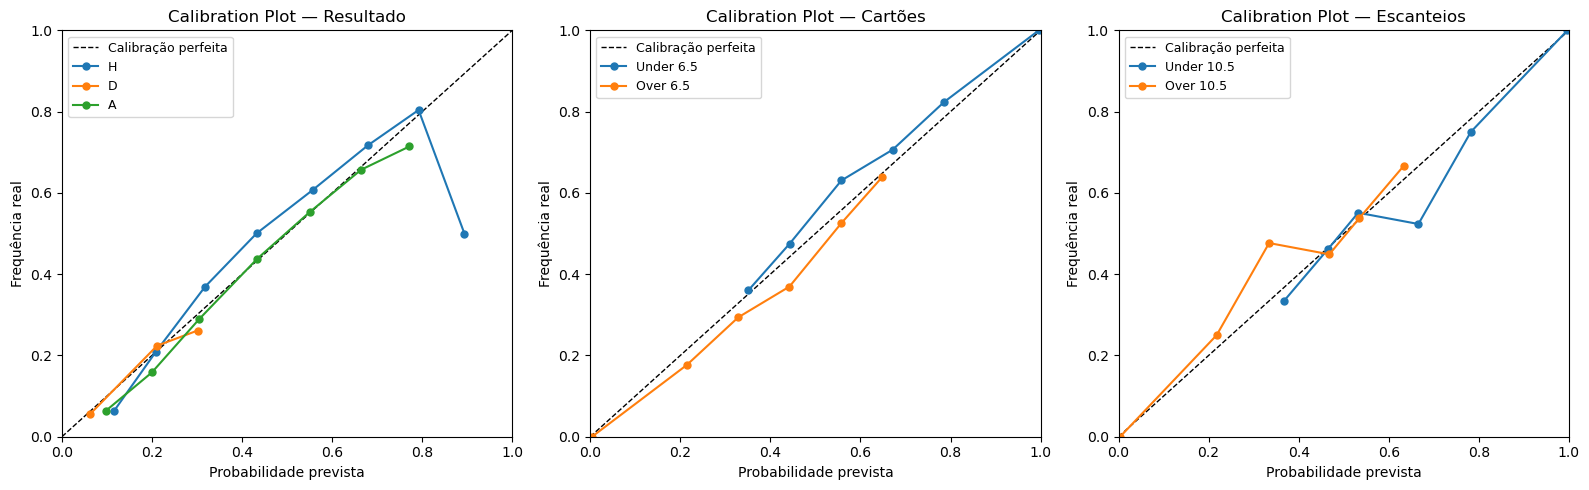

Quanto mais próxima a linha da diagonal, mais calibrado o modelo.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, probs, truths, labels) in zip(axes, [
    ("Resultado",  probs_r, true_r, ["H","D","A"]),
    ("Cartões",    probs_y, true_y, ["Under 6.5",  "Over 6.5"]),
    ("Escanteios", probs_c, true_c, ["Under 10.5", "Over 10.5"]),
]):
    ax.plot([0,1],[0,1], "k--", lw=1, label="Calibração perfeita")
    for cls_idx, label in enumerate(labels):
        prob_true, prob_pred = calibration_curve(
            (truths == cls_idx).astype(int),
            probs[:, cls_idx],
            n_bins=8, strategy="uniform"
        )
        ax.plot(prob_pred, prob_true, "o-", ms=5, label=label)
    ax.set_title(f"Calibration Plot — {name}")
    ax.set_xlabel("Probabilidade prevista"); ax.set_ylabel("Frequência real")
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout(); plt.show()
print("Quanto mais próxima a linha da diagonal, mais calibrado o modelo.")


## 11. Salvando o Modelo

In [12]:
WINDOW = 10

In [13]:
model_path = MODELS_DIR / "oscabet_nn_v1.pt"
meta_path  = MODELS_DIR / "oscabet_nn_v1_meta.json"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim":        X_train.shape[1],
    "feat_cols":        feat_cols,
    "train_cutoff":     TRAIN_CUTOFF_DATE,
    "hyperparams": {
        "epochs": EPOCHS, "lr": LR, "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE, "window": WINDOW,
    },
    "metrics": {k: {m: float(v) for m, v in val.items() if isinstance(v, float)}
                for k, val in metrics.items()},
}, model_path)

with open(meta_path, "w") as f:
    json.dump({
        "input_dim": int(X_train.shape[1]),
        "feat_cols": feat_cols,
        "train_cutoff": TRAIN_CUTOFF_DATE,
        "n_train": int(len(X_train)),
        "n_val":   int(len(X_val)),
        "metrics": {k: {m: round(float(v), 4) for m, v in val.items() if isinstance(v, float)}
                    for k, val in metrics.items()},
    }, f, indent=2, ensure_ascii=False)

print(f"✅ Modelo salvo em: {model_path}")
print(f"✅ Metadados em:    {meta_path}")


✅ Modelo salvo em: G:\ian\prog\oscabet_IA_Logica_1s\agent\models\oscabet_nn_v1.pt
✅ Metadados em:    G:\ian\prog\oscabet_IA_Logica_1s\agent\models\oscabet_nn_v1_meta.json
